# 02 — Regime Detection

Notebook 01 showed that crises are not all alike: in **2008 and 2020** bonds hedged stocks (*growth shocks*), but in **2022** stocks and bonds fell together (*rate shock*).

Here we fit a **Gaussian Hidden Markov Model**: it assumes the market switches between a few hidden "regimes", each with its own typical behaviour, and that regimes are persistent (today's regime is likely tomorrow's). The model sees four features, so it can tell different kinds of stress apart:

| Feature | Meaning |
|---|---|
| `spy_ret` | SPY return over the last month |
| `spy_vol` | SPY annualized volatility over the last month |
| `tlt_ret` | TLT return over the last month |
| `stock_bond_corr` | SPY–TLT correlation over the last 3 months |

All logic lives in `src/regimes.py`.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from src.data import download_prices, compute_returns
from src.regimes import (
    build_features, compare_n_states, fit_hmm, predict_regimes, regime_profile,
    asset_performance_by_regime, regime_durations, transition_matrix, save_model,
)

## 1. Features

In [2]:
prices = download_prices()          # loads data/raw/prices.csv from Step 1
returns = compute_returns(prices)
features = build_features(returns)
print(features.shape)
features.describe().round(3)

(5386, 4)


,spy_ret,spy_vol,tlt_ret,stock_bond_corr
count,5386.000,5386.000,5386.000,5386.000
mean,0.009,0.157,0.002,-0.252
std,0.047,0.110,0.039,0.308
min,-0.397,0.034,-0.161,-0.837
25%,-0.010,0.094,-0.021,-0.508
50%,0.016,0.130,0.002,-0.291
75%,0.035,0.183,0.026,-0.016
max,0.225,0.937,0.236,0.569


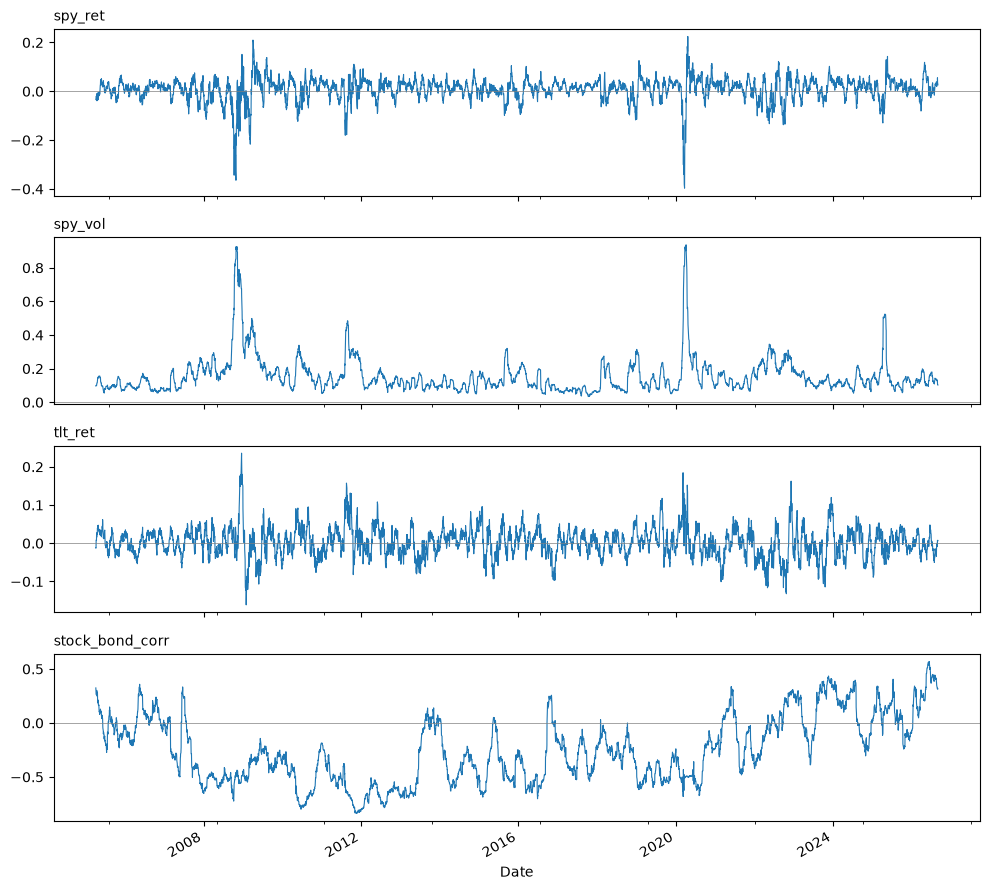

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for ax, col in zip(axes, features.columns):
    features[col].plot(ax=ax, linewidth=0.8)
    ax.set_title(col, loc="left", fontsize=10)
    ax.axhline(0, color="grey", linewidth=0.5)
plt.tight_layout()
plt.show()

## 2. How many regimes?
More regimes always fit better, so we use **BIC**, which penalizes extra parameters. Lower is better. We also want regimes we can interpret.

In [4]:
comparison = compare_n_states(features, candidates=(2, 3, 4))
comparison.round(1)

,log_likelihood,bic
n_states,,
2,-23927.5,48121.3
3,-20989.9,42409.4
4,-19015.5,38641.1


## 3. Fit the model
We use **3 regimes** (calm / growth shock / rate shock was our hypothesis from Step 1). Regimes are numbered by SPY volatility: **0 = calmest**.

In [5]:
N_STATES = 3

model, scaler, ll, bic = fit_hmm(features, n_states=N_STATES)
regimes, remap = predict_regimes(model, scaler, features)
save_model(model, scaler, remap)
print(f"log-likelihood: {ll:.1f} | BIC: {bic:.1f}")
regimes.value_counts().sort_index()

log-likelihood: -20985.6 | BIC: 42400.7


regime
0    2065
1    2328
2     993
Name: count, dtype: int64

## 4. What does each regime look like?

In [6]:
regime_profile(features, regimes).round(3)

,spy_ret,spy_vol,tlt_ret,stock_bond_corr,share_of_days
regime,,,,,
0,0.016,0.107,-0.003,0.033,0.383
1,0.012,0.134,0.009,-0.489,0.432
2,-0.013,0.313,-0.001,-0.289,0.184


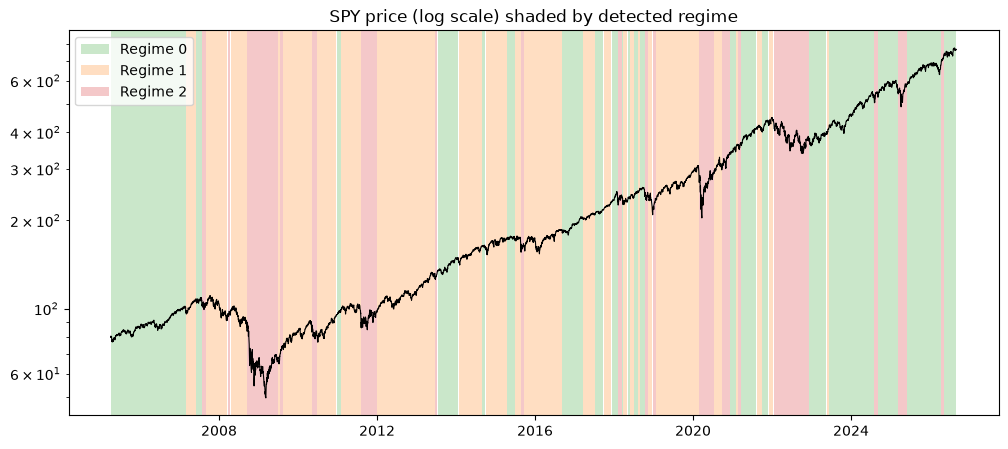

In [7]:
colors = {0: "tab:green", 1: "tab:orange", 2: "tab:red", 3: "tab:purple"}

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prices.loc[regimes.index, "SPY"], color="black", linewidth=0.8)
ax.set_yscale("log")
for k in sorted(regimes.unique()):
    ax.fill_between(regimes.index, 0, 1, where=(regimes == k),
                    transform=ax.get_xaxis_transform(),
                    color=colors[k], alpha=0.25, linewidth=0, label=f"Regime {k}")
ax.set_title("SPY price (log scale) shaded by detected regime")
ax.legend(loc="upper left")
plt.show()

## 5. How do the assets behave in each regime?
This is what matters for the portfolio. Returns are measured the day **after** the regime is observed.

In [8]:
ann_ret, ann_vol, sharpe = asset_performance_by_regime(returns, regimes)
print("Annualized return by regime:")
display(ann_ret.round(3))
print("Sharpe ratio by regime:")
display(sharpe.round(2))

Annualized return by regime:


,SPY,TLT,GLD
regime,,,
0,0.130,-0.022,0.135
1,0.090,0.101,0.081
2,0.093,-0.032,0.103


Sharpe ratio by regime:


,SPY,TLT,GLD
regime,,,
0,1.12,-0.18,0.76
1,0.61,0.78,0.50
2,0.27,-0.15,0.45


## 6. Persistence
If regimes flipped every day they would be useless for investing. The diagonal of the transition matrix is the probability of staying in the same regime tomorrow.

In [9]:
print("Average stay (trading days):")
display(regime_durations(regimes).round(1))
print("Daily transition probabilities (row = today, column = tomorrow):")
transition_matrix(model, remap).round(3)

Average stay (trading days):


regime
0    98.3
1    97.0
2    55.2
Name: avg_days, dtype: float64

Daily transition probabilities (row = today, column = tomorrow):


,0,1,2
0,0.990,0.007,0.003
1,0.005,0.990,0.005
2,0.008,0.010,0.982


## 7. Does it catch the crises?

In [10]:
crises = {
    "2008 financial crisis": ("2007-10-09", "2009-03-09"),
    "COVID crash":           ("2020-02-19", "2020-03-23"),
    "2022 rate hikes":       ("2022-01-03", "2022-10-12"),
}
rows = {name: regimes.loc[s:e].value_counts(normalize=True).sort_index() for name, (s, e) in crises.items()}
pd.DataFrame(rows).T.fillna(0).round(2)

regime,1,2
2008 financial crisis,0.61,0.39
COVID crash,0.25,0.75
2022 rate hikes,0.05,0.95


## 8. Key numbers (text summary)

In [11]:
print("Model comparison (lower BIC = better):")
print(comparison.round(1).to_string())
print("\nDays per regime:")
print(regimes.value_counts().sort_index().to_string())
print("\nRegime profile:")
print(regime_profile(features, regimes).round(3).to_string())
print("\nAnnualized return by regime:")
print(ann_ret.round(3).to_string())
print("\nSharpe by regime:")
print(sharpe.round(2).to_string())
print("\nAverage stay (days):")
print(regime_durations(regimes).round(1).to_string())
print("\nTransition matrix:")
print(transition_matrix(model, remap).round(3).to_string())
print("\nRegime mix during crises:")
print(pd.DataFrame(rows).T.fillna(0).round(2).to_string())

Model comparison (lower BIC = better):
          log_likelihood      bic
n_states                         
2               -23927.5  48121.3
3               -20989.9  42409.4
4               -19015.5  38641.1

Days per regime:
regime
0    2065
1    2328
2     993

Regime profile:
        spy_ret  spy_vol  tlt_ret  stock_bond_corr  share_of_days
regime                                                           
0         0.016    0.107   -0.003            0.033          0.383
1         0.012    0.134    0.009           -0.489          0.432
2        -0.013    0.313   -0.001           -0.289          0.184

Annualized return by regime:
          SPY    TLT    GLD
regime                     
0       0.130 -0.022  0.135
1       0.090  0.101  0.081
2       0.093 -0.032  0.103

Sharpe by regime:
         SPY   TLT   GLD
regime                  
0       1.12 -0.18  0.76
1       0.61  0.78  0.50
2       0.27 -0.15  0.45

Average stay (days):
regime
0    98.3
1    97.0
2    55.2

Transition matr

## Takeaways

The 3-regime HMM found three persistent market environments (98–99% chance of staying in the same regime each day):

| | Regime 0 | Regime 1 | Regime 2 |
|---|---|---|---|
| **Name** | Calm, bonds don't hedge | Calm, bonds hedge | Stress |
| Share of days | 38% | 43% | 18% |
| SPY volatility | 10.7% | 13.4% | 31.3% |
| Stock–bond correlation | +0.03 | −0.49 | −0.29 |
| Average stay | 98 days | 97 days | 55 days |
| Sharpe SPY / TLT / GLD | **1.12** / −0.18 / 0.76 | 0.61 / **0.78** / 0.50 | 0.27 / −0.15 / **0.45** |

**1. Each regime has a different best asset:** stocks when calm without hedging, bonds when they hedge, gold in stress.

**2. Bonds only help in one regime.** TLT has negative Sharpe in regime 0 and in stress, which includes 95% of 2022.

**3. Stress does not mean exit stocks.** SPY's next-day return stays positive in stress (rebound days), but its Sharpe falls to 0.27, so stocks should be reduced, not removed.

*Caveat: regimes are estimated on the full sample (in-sample). The backtest in Step 4 re-estimates them using only past data.*